# Head, mask and negative comparisons

We examine the magnitude and repeatability of differences. We separate controlled weighted-BCE/PN-BCE pairs from broader comparisons between objective families.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_4_head_negative_comparisons_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:27:05,755 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:27:05,758 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:27:06,088 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:27:06,090 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:27:06,091 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:27:06,092 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Paired differences between conditions

### Methodology

#### Theoretical

For every shared seed, compute Δ=metric_left-metric_right. The descriptive interval is mean(Δ) ± t_0.975,n-1 * sd(Δ)/sqrt(n). It describes training variability on one fixed split, not uncertainty across patients.

#### Implementation

Duplicates of the same condition and seed are averaged; their range is retained. Match only actual seeds, data, backbone and training settings outside the head loss that agree. Missing pairs are explicit. Intervals are exploratory, without correction for the number of comparisons or significance claims.

#### Figure descriptions

Tables contain each Δ, its mean and median, the number of positive differences and the interval. A positive AP/AUC difference favours left. The plot shows all matched seeds for comparisons with historical BCE.


2026-09-08 10:27:11,024 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,left,right,left_source,right_source,left_condition,right_condition,split,population,scope,metric,pairs,mean_difference,median_difference,positive_pairs,ci_low,ci_high,reason
0,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,test,annotation_retrieval,frequent,ap_above_prevalence,5,-0.003156,-0.004397,1,-0.007513,0.001201,Exploratory unadjusted interval across seeds
1,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,test,annotation_retrieval,frequent,average_precision,5,-0.003156,-0.004397,1,-0.007513,0.001201,Exploratory unadjusted interval across seeds
2,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,test,annotation_retrieval,frequent,roc_auc,5,0.000055,-0.000045,2,-0.000223,0.000334,Exploratory unadjusted interval across seeds
3,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,test,annotation_retrieval,medium,ap_above_prevalence,5,0.002685,0.009791,3,-0.033612,0.038983,Exploratory unadjusted interval across seeds
4,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,test,annotation_retrieval,medium,average_precision,5,0.002685,0.009791,3,-0.033612,0.038983,Exploratory unadjusted interval across seeds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2587,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,rare,average_precision,5,0.027860,0.027031,3,-0.013783,0.069504,Exploratory unadjusted interval across seeds
2588,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,rare,roc_auc,5,0.008388,0.006995,5,0.000351,0.016424,Exploratory unadjusted interval across seeds
2589,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,train_supported,ap_above_prevalence,5,0.015676,0.016067,5,0.012487,0.018865,Exploratory unadjusted interval across seeds
2590,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,train_supported,average_precision,5,0.015676,0.016067,5,0.012487,0.018865,Exploratory unadjusted interval across seeds


2026-09-08 10:27:14,503 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 3 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_4_head_negative_comparisons_results.


,left,right,left_source,right_source,left_condition,right_condition,split,population,scope,metric,pairs,mean_difference,median_difference,positive_pairs,ci_low,ci_high,reason,weight_mode,interpretation
0,bce_global_positive_penalty (PositiveWeightedM...,pn_bce_global_positive_penalty (SignalMaskedBC...,predictive_initial,predictive_initial,061bcbfb8c04,40ee4c7e8820,test,annotation_retrieval,frequent,ap_above_prevalence,5,0.077198,0.074591,5,0.069100,0.085297,Exploratory unadjusted interval across seeds,global_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
1,bce_global_positive_penalty (PositiveWeightedM...,pn_bce_global_positive_penalty (SignalMaskedBC...,predictive_initial,predictive_initial,061bcbfb8c04,40ee4c7e8820,test,annotation_retrieval,frequent,average_precision,5,0.077198,0.074591,5,0.069100,0.085297,Exploratory unadjusted interval across seeds,global_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
2,bce_global_positive_penalty (PositiveWeightedM...,pn_bce_global_positive_penalty (SignalMaskedBC...,predictive_initial,predictive_initial,061bcbfb8c04,40ee4c7e8820,test,annotation_retrieval,frequent,roc_auc,5,0.012982,0.013162,5,0.011550,0.014413,Exploratory unadjusted interval across seeds,global_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
3,bce_global_positive_penalty (PositiveWeightedM...,pn_bce_global_positive_penalty (SignalMaskedBC...,predictive_initial,predictive_initial,061bcbfb8c04,40ee4c7e8820,test,annotation_retrieval,medium,ap_above_prevalence,5,0.027707,0.036187,4,-0.001696,0.057110,Exploratory unadjusted interval across seeds,global_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
4,bce_global_positive_penalty (PositiveWeightedM...,pn_bce_global_positive_penalty (SignalMaskedBC...,predictive_initial,predictive_initial,061bcbfb8c04,40ee4c7e8820,test,annotation_retrieval,medium,average_precision,5,0.027707,0.036187,4,-0.001696,0.057110,Exploratory unadjusted interval across seeds,global_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,rare,average_precision,5,0.027860,0.027031,3,-0.013783,0.069504,Exploratory unadjusted interval across seeds,per_class_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
140,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,rare,roc_auc,5,0.008388,0.006995,5,0.000351,0.016424,Exploratory unadjusted interval across seeds,per_class_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
141,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,train_supported,ap_above_prevalence,5,0.015676,0.016067,5,0.012487,0.018865,Exploratory unadjusted interval across seeds,per_class_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...
142,pn_bce_per_class_positive_penalty (SignalMaske...,bce_per_class_positive_penalty (PositiveWeight...,predictive_initial,predictive_initial,d1f9a150e163,e27ded54dfca,validation,operational_pn,train_supported,average_precision,5,0.015676,0.016067,5,0.012487,0.018865,Exploratory unadjusted interval across seeds,per_class_sqrt_negative_to_positive,U masking plus changed P/N-derived weights; si...


2026-09-08 10:27:15,203 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_4_head_negative_comparisons_results.


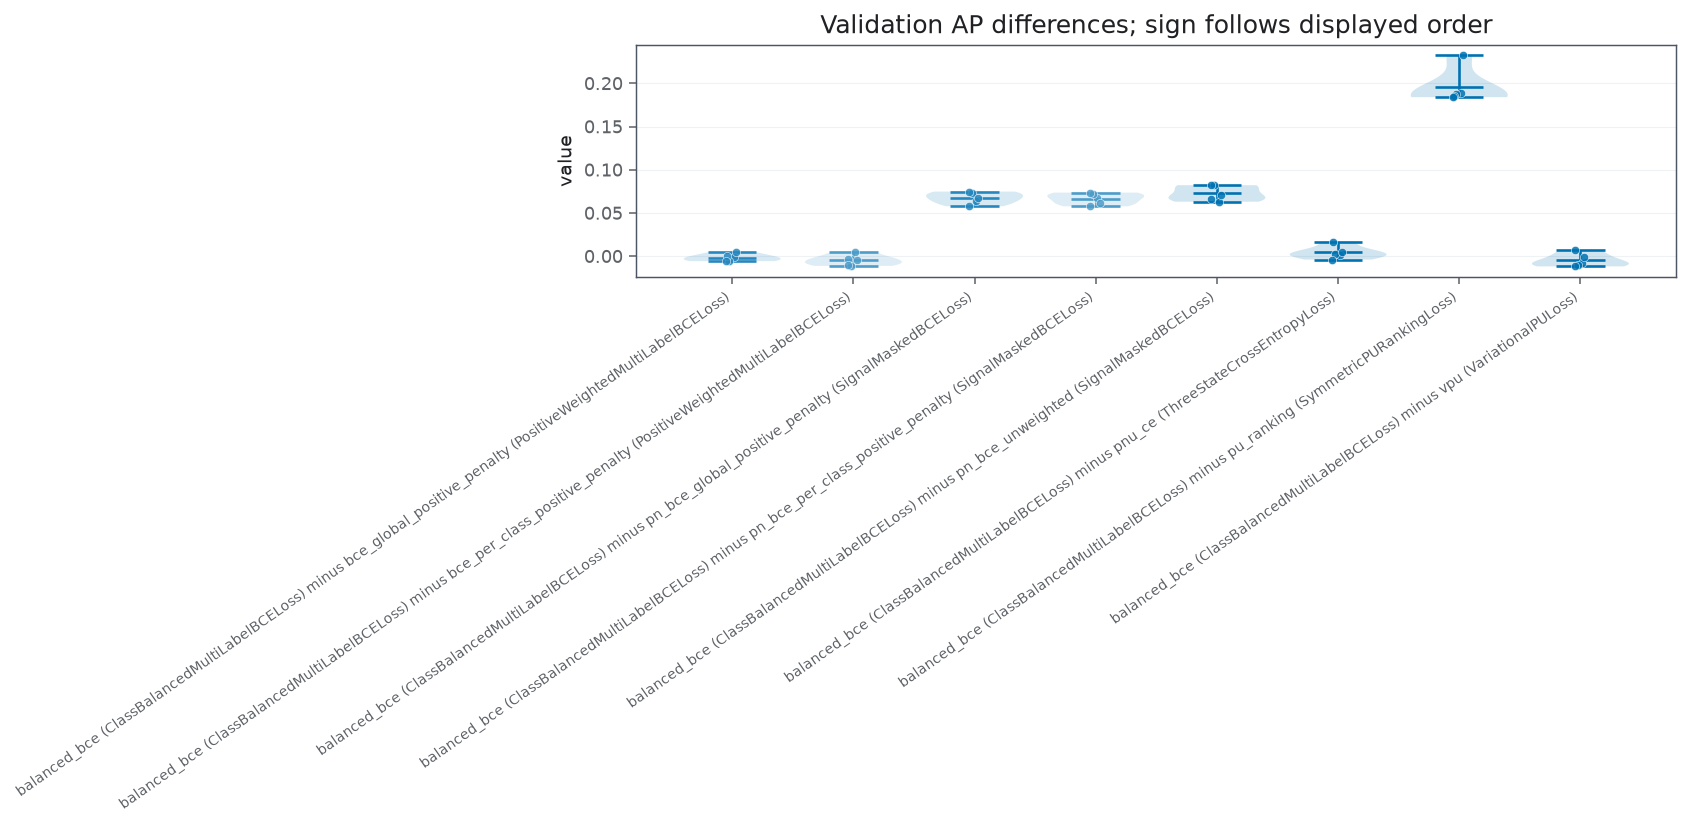

In [2]:
models, _ = campaign.inventory(settings)
prediction = cache.load_table(settings, "prediction")
keys = ["split", "population", "scope", "metric"]
units = reports.experimental_units(prediction, models, keys)
differences, contrasts = reports.paired_comparisons(units, keys)
display(contrasts)
if not differences.empty:
    selected = differences.query("split == 'validation' and scope == 'train_supported' and metric == 'average_precision' and population == 'annotation_retrieval'").copy()
    selected = selected[(selected.left_source == "historical_bce") | (selected.right_source == "historical_bce")]
    selected["label"] = selected.left + " minus " + selected.right
    plots.distributions(selected, title="Validation AP differences; sign follows displayed order").savefig(RESULTS / "baseline_differences.png")
reports.save_tables(RESULTS, experimental_units=units, paired_differences=differences, contrasts=contrasts)
masking = reports.masking_contrasts(contrasts, models)
display(masking)
reports.save_tables(RESULTS, matched_bce_masking=masking)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## What the current experiment identifies

### Methodology

#### Theoretical

Weighted BCE versus PN-BCE with the same weight_mode examines a change in the treatment of missing annotations and the resulting change in effective P/N weights. VPU and PU-ranking without an additional N penalty address the promise of a family but do not identify the increment from adding negatives.

#### Implementation

The exact parameters of each family are shown from saved manifests. Four pairs of entries in the current YAML are duplicates, not a threshold sweep. CE uses an evidence rule to construct its training states; CE ranking itself remains threshold-free.

#### Figure descriptions

The table is an intervention map, not a figure. Compare family, weight_mode, head_weight, negative_weight and evidence before interpreting a difference.


In [3]:
display(models[["condition", "label", "family", "weight_mode", "head_weight", "negative_weight", "evidence", "objective_json"]].drop_duplicates())
reports.save_tables(RESULTS, intervention_map=models[["condition", "label", "family", "weight_mode", "head_weight", "negative_weight", "evidence", "objective_json"]].drop_duplicates())

,condition,label,family,weight_mode,head_weight,negative_weight,evidence,objective_json
0,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,PositiveWeightedMultiLabelBCELoss,global_sqrt_negative_to_positive,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""bce_global_pos..."
5,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,PositiveWeightedMultiLabelBCELoss,per_class_sqrt_negative_to_positive,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""bce_per_class_..."
10,a4c7ac80c5c1,pn_bce_unweighted (SignalMaskedBCELoss),SignalMaskedBCELoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_unweigh..."
20,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,SignalMaskedBCELoss,global_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_global_..."
30,d1f9a150e163,pn_bce_per_class_positive_penalty (SignalMaske...,SignalMaskedBCELoss,per_class_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_per_cla..."
40,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),ThreeStateCrossEntropyLoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_pnu"": {""pnu_ce"": {""params..."
50,c37325811656,vpu (VariationalPULoss),VariationalPULoss,none,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""vpu"": {""params..."
55,32e2c5ffe6e2,pu_ranking (SymmetricPURankingLoss),SymmetricPURankingLoss,none,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""pu_ranking"": {..."
60,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),ClassBalancedMultiLabelBCELoss,none,0.2,0.0,{},"{""heads"": {""molecule_primary"": {""balanced_bce""..."


2026-09-08 10:27:15,606 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_4_head_negative_comparisons_results.


### Remarks

This campaign contains neither nnPU nor an independent pretraining/contractivity/contrastivity sweep. Historical BCE uses a different weighting definition from the new BCE variants. Equal coefficients of 0.2 do not imply equal gradient strength across objectives.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
